# Stage 4 — Hiperparametrización con Optuna

**Objetivo:** Optimizar los 5 modelos baseline usando Optuna y elegir el mejor candidato final.

**Métrica objetivo:** F1 de clase 0 (insatisfechos) — porque el error más costoso es no detectar un cliente que se va a ir.

**Regla de oro:** El test set NO se toca hasta haber elegido el modelo final.

## 1. Imports y configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import logging
warnings.filterwarnings('ignore')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # silenciar logs por trial

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

SEED       = 2357
N_TRIALS   = 100    # trials por modelo — aumentar si tienes tiempo
TARGET_COL = 'satisfecho'   # ← ajusta si es necesario
POS_LABEL  = 0     # clase que nos importa: insatisfecho

print('Librerías cargadas ✓')
print(f'Optuna versión: {optuna.__version__}')

Librerías cargadas ✓
Optuna versión: 4.9.0


## 2. Carga de datos

In [27]:
DATA = "data/master/"
# ── Ajusta las rutas a tu estructura de carpetas ──
X_TRAIN_PATH = f'{DATA}X_train.csv'
X_VAL_PATH   = f'{DATA}X_val.csv'
X_TEST_PATH  = f'{DATA}X_backtest.csv'
Y_TRAIN_PATH = f'{DATA}y_train.csv'
Y_VAL_PATH   = f'{DATA}y_val.csv'
Y_TEST_PATH  = f'{DATA}y_backtest.csv'

X_train = pd.read_csv(X_TRAIN_PATH)
X_val   = pd.read_csv(X_VAL_PATH)
X_test  = pd.read_csv(X_TEST_PATH)

y_train = pd.read_csv(Y_TRAIN_PATH)
y_val   = pd.read_csv(Y_VAL_PATH)
y_test  = pd.read_csv(Y_TEST_PATH)

# Ratio para scale_pos_weight en XGBoost/LightGBM
# = n_negativos / n_positivos  (negativos = insatisfechos = clase 0)
neg = int(np.sum(y_train == 0))
pos = int(np.sum(y_train == 1))
SPW = round(pos / neg, 4)   # scale_pos_weight penaliza la clase 1 (satisfecho)
                            # para que el modelo preste más atención al 0

print(f'Train: {X_train.shape} | insatisfechos: {(y_train==0).mean().item():.2%}')
print(f'Val:   {X_val.shape}   | insatisfechos: {(y_val==0).mean().item():.2%}')
print(f'scale_pos_weight para boosting: {SPW}')

Train: (43294, 25) | insatisfechos: 20.64%
Val:   (20374, 25)   | insatisfechos: 27.31%
scale_pos_weight para boosting: 3.8438


## 3. Función de evaluación común

Centraliza el cálculo de métricas para no repetir código en cada objective.

In [6]:
def metricas(y_true, y_pred, y_proba):
    """Devuelve dict de métricas. pos_label=0 porque nos importan los insatisfechos."""
    return {
        'f1_0'     : f1_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0),
        'recall_0' : recall_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0),
        'prec_0'   : precision_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0),
        'f1_macro' : f1_score(y_true, y_pred, average='macro', zero_division=0),
        'auc'      : roc_auc_score(y_true, y_proba),
    }

## 4. Objective functions

Cada función define el espacio de búsqueda para un modelo.
Optuna llama a estas funciones `N_TRIALS` veces con distintos parámetros y maximiza el valor retornado.

**Patrón:**
```
trial.suggest_float('param', low, high)        # continuo
trial.suggest_int('param', low, high)          # entero
trial.suggest_categorical('param', [a, b, c])  # categórico
```

In [28]:
# ── Logistic Regression ──────────────────────────────────────────────────────
def objective_lr(trial):
    params = {
        'C'           : trial.suggest_float('C', 1e-3, 10, log=True),
        'solver'      : trial.suggest_categorical('solver', ['lbfgs', 'saga']),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'max_iter'    : 1000,
        'random_state': SEED,
    }
    model = LogisticRegression(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_val)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    return f1_score(y_val, pred, pos_label=POS_LABEL, zero_division=0)


# ── Random Forest ─────────────────────────────────────────────────────────────
def objective_rf(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        'class_weight'     : trial.suggest_categorical('class_weight', [None, 'balanced']),
        'random_state'     : SEED,
        'n_jobs'           : -2,
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_val)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    return f1_score(y_val, pred, pos_label=POS_LABEL, zero_division=0)


# ── Gradient Boosting (sklearn) ───────────────────────────────────────────────
def objective_gb(trial):
    params = {
        'n_estimators'  : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'     : trial.suggest_int('max_depth', 2, 8),
        'learning_rate' : trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample'     : trial.suggest_float('subsample', 0.5, 1.0),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features'  : trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state'  : SEED,
    }
    # GradientBoostingClassifier no tiene class_weight → usamos sample_weight
    sw = np.where(y_train.to_numpy().ravel() == POS_LABEL,
                  len(y_train) / (2 * (y_train == POS_LABEL).sum()),
                  len(y_train) / (2 * (y_train != POS_LABEL).sum()))
    sw = sw.ravel()
    use_weight = trial.suggest_categorical('use_sample_weight', [True, False])

    model = GradientBoostingClassifier(**params)
    model.fit(X_train, y_train, sample_weight=sw if use_weight else None)
    proba = model.predict_proba(X_val)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    return f1_score(y_val, pred, pos_label=POS_LABEL, zero_division=0)


# ── XGBoost ───────────────────────────────────────────────────────────────────
def objective_xgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 2, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'scale_pos_weight' : trial.suggest_categorical('scale_pos_weight', [1, SPW, SPW*1.5]),
        'random_state'     : SEED,
        'eval_metric'      : 'logloss',
        'verbosity'        : 0,
        'n_jobs'           : -2,
    }
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_val)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    return f1_score(y_val, pred, pos_label=POS_LABEL, zero_division=0)


# ── LightGBM ──────────────────────────────────────────────────────────────────
def objective_lgbm(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 2, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'class_weight'     : trial.suggest_categorical('class_weight', [None, 'balanced']),
        'random_state'     : SEED,
        'verbosity'        : -1,
        'n_jobs'           : -2,
    }
    model = LGBMClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_val)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    return f1_score(y_val, pred, pos_label=POS_LABEL, zero_division=0)


print('Objective functions definidas ✓')

Objective functions definidas ✓


## 5. Ejecución de estudios Optuna

Cada modelo corre un `study` independiente. Optuna usa el algoritmo TPE (Tree-structured Parzen Estimator) por defecto — aprende qué zonas del espacio de parámetros son prometedoras a medida que avanza.

In [29]:
import time

ESTUDIOS = {
    'Logistic Regression': objective_lr,
    'Random Forest'      : objective_rf,
    'Gradient Boosting'  : objective_gb,
    'XGBoost'            : objective_xgb,
    'LightGBM'           : objective_lgbm,
}

estudios_completados = {}   # guardamos los study objects para análisis posterior

for nombre, objective in ESTUDIOS.items():
    print(f'\n▶ Optimizando {nombre} ({N_TRIALS} trials)...')
    t0 = time.time()

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
        study_name=nombre,
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    estudios_completados[nombre] = study
    elapsed = time.time() - t0
    print(f'  ✓ Mejor F1(clase 0): {study.best_value:.4f} | Tiempo: {elapsed:.0f}s')
    print(f'  Mejores params: {study.best_params}')

print('\n✓ Todos los estudios completados')


▶ Optimizando Logistic Regression (100 trials)...


Best trial: 92. Best value: 0.558025: 100%|██████████| 100/100 [00:52<00:00,  1.90it/s]


  ✓ Mejor F1(clase 0): 0.5580 | Tiempo: 53s
  Mejores params: {'C': 0.00470926704826181, 'solver': 'lbfgs', 'class_weight': 'balanced'}

▶ Optimizando Random Forest (100 trials)...


Best trial: 23. Best value: 0.576501: 100%|██████████| 100/100 [05:00<00:00,  3.01s/it]


  ✓ Mejor F1(clase 0): 0.5765 | Tiempo: 301s
  Mejores params: {'n_estimators': 440, 'max_depth': 3, 'min_samples_split': 13, 'min_samples_leaf': 10, 'max_features': 'log2', 'class_weight': 'balanced'}

▶ Optimizando Gradient Boosting (100 trials)...


...

  ✓ Mejor F1(clase 0): 0.5774 | Tiempo: 1181s
  Mejores params: {'n_estimators': 316, 'max_depth': 2, 'learning_rate': 0.0010347078751807833, 'subsample': 0.9238825823691569, 'min_samples_leaf': 18, 'max_features': 'log2', 'use_sample_weight': True}

▶ Optimizando XGBoost (100 trials)...


Best trial: 89. Best value: 0.525077: 100%|██████████| 100/100 [01:01<00:00,  1.61it/s]


  ✓ Mejor F1(clase 0): 0.5251 | Tiempo: 62s
  Mejores params: {'n_estimators': 251, 'max_depth': 2, 'learning_rate': 0.08003910486515482, 'subsample': 0.5588629446218238, 'colsample_bytree': 0.56473003515822, 'reg_alpha': 2.2635563940566862e-06, 'reg_lambda': 0.014866675635349685, 'scale_pos_weight': 1}

▶ Optimizando LightGBM (100 trials)...


Best trial: 14. Best value: 0.571684: 100%|██████████| 100/100 [00:57<00:00,  1.73it/s]

  ✓ Mejor F1(clase 0): 0.5717 | Tiempo: 58s
  Mejores params: {'n_estimators': 496, 'max_depth': 2, 'learning_rate': 0.0011682532434575004, 'num_leaves': 48, 'subsample': 0.9022015171623567, 'colsample_bytree': 0.7826011815621131, 'reg_alpha': 1.0243016896195631e-05, 'reg_lambda': 0.0024468745059448974, 'class_weight': 'balanced'}

✓ Todos los estudios completados


## 6. Re-entrenamiento con mejores parámetros y evaluación completa

In [30]:
def construir_modelo(nombre, params):
    """Reconstruye el modelo con los parámetros óptimos encontrados por Optuna."""
    p = params.copy()

    if nombre == 'Logistic Regression':
        return LogisticRegression(**p, max_iter=1000, random_state=SEED)

    if nombre == 'Random Forest':
        return RandomForestClassifier(**p, random_state=SEED, n_jobs=-2)

    if nombre == 'Gradient Boosting':
        use_weight = p.pop('use_sample_weight')
        return GradientBoostingClassifier(**p, random_state=SEED), use_weight

    if nombre == 'XGBoost':
        return XGBClassifier(**p, random_state=SEED, eval_metric='logloss',
                             verbosity=0, n_jobs=-2)

    if nombre == 'LightGBM':
        return LGBMClassifier(**p, random_state=SEED, verbosity=-1, n_jobs=-2)


resultados_optuna = []

for nombre, study in estudios_completados.items():
    best_params = study.best_params.copy()

    # Manejo especial de Gradient Boosting por sample_weight
    if nombre == 'Gradient Boosting':
        resultado = construir_modelo(nombre, best_params)
        model, use_weight = resultado
        sw = np.where(y_train.to_numpy().ravel() == POS_LABEL,
                      len(y_train) / (2 * (y_train == POS_LABEL).sum()),
                      len(y_train) / (2 * (y_train != POS_LABEL).sum()))
        sw = sw.ravel()
        model.fit(X_train, y_train, sample_weight=sw if use_weight else None)
    else:
        model = construir_modelo(nombre, best_params)
        model.fit(X_train, y_train)

    proba = model.predict_proba(X_val)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    m     = metricas(y_val, pred, proba)

    resultados_optuna.append({
        'Modelo'   : nombre,
        'F1(cls 0)': round(m['f1_0'],     4),
        'Rec(cls 0)': round(m['recall_0'], 4),
        'Pre(cls 0)': round(m['prec_0'],   4),
        'F1 macro' : round(m['f1_macro'],  4),
        'AUC-ROC'  : round(m['auc'],       4),
        '_proba'   : proba,
        '_model'   : model,
        '_params'  : best_params,
    })

print('✓ Re-entrenamiento completado')

✓ Re-entrenamiento completado


## 7. Tabla comparativa: Baseline vs Optuna

In [32]:
cols = ['Modelo', 'F1(cls 0)', 'Rec(cls 0)', 'Pre(cls 0)', 'F1 macro', 'AUC-ROC']
df_optuna = pd.DataFrame(resultados_optuna)[cols].sort_values('F1(cls 0)', ascending=False)

def highlight_best(s):
    if s.name == 'Modelo': return ['' for _ in s]
    is_best = s == s.max()
    return ['background-color: #002357; font-weight: bold' if v else '' for v in is_best]

print('Resultados post-Optuna (ordenados por F1 clase 0):')
df_optuna.style.apply(highlight_best).set_caption('Validación — métricas con parámetros óptimos')

Resultados post-Optuna (ordenados por F1 clase 0):


,Modelo,F1(cls 0),Rec(cls 0),Pre(cls 0),F1 macro,AUC-ROC
2,Gradient Boosting,0.577400,0.552700,0.604400,0.713900,0.758200
1,Random Forest,0.576500,0.571800,0.581300,0.709600,0.761300
4,LightGBM,0.571700,0.575000,0.568400,0.704700,0.755900
0,Logistic Regression,0.558000,0.670100,0.478100,0.671200,0.763100
3,XGBoost,0.525100,0.381000,0.844600,0.703900,0.765600


## 8. Curvas de optimización por modelo

Muestra cómo fue mejorando el F1(clase 0) a lo largo de los trials. Si la curva se aplana antes del trial 50, los parámetros están bien convergidos.

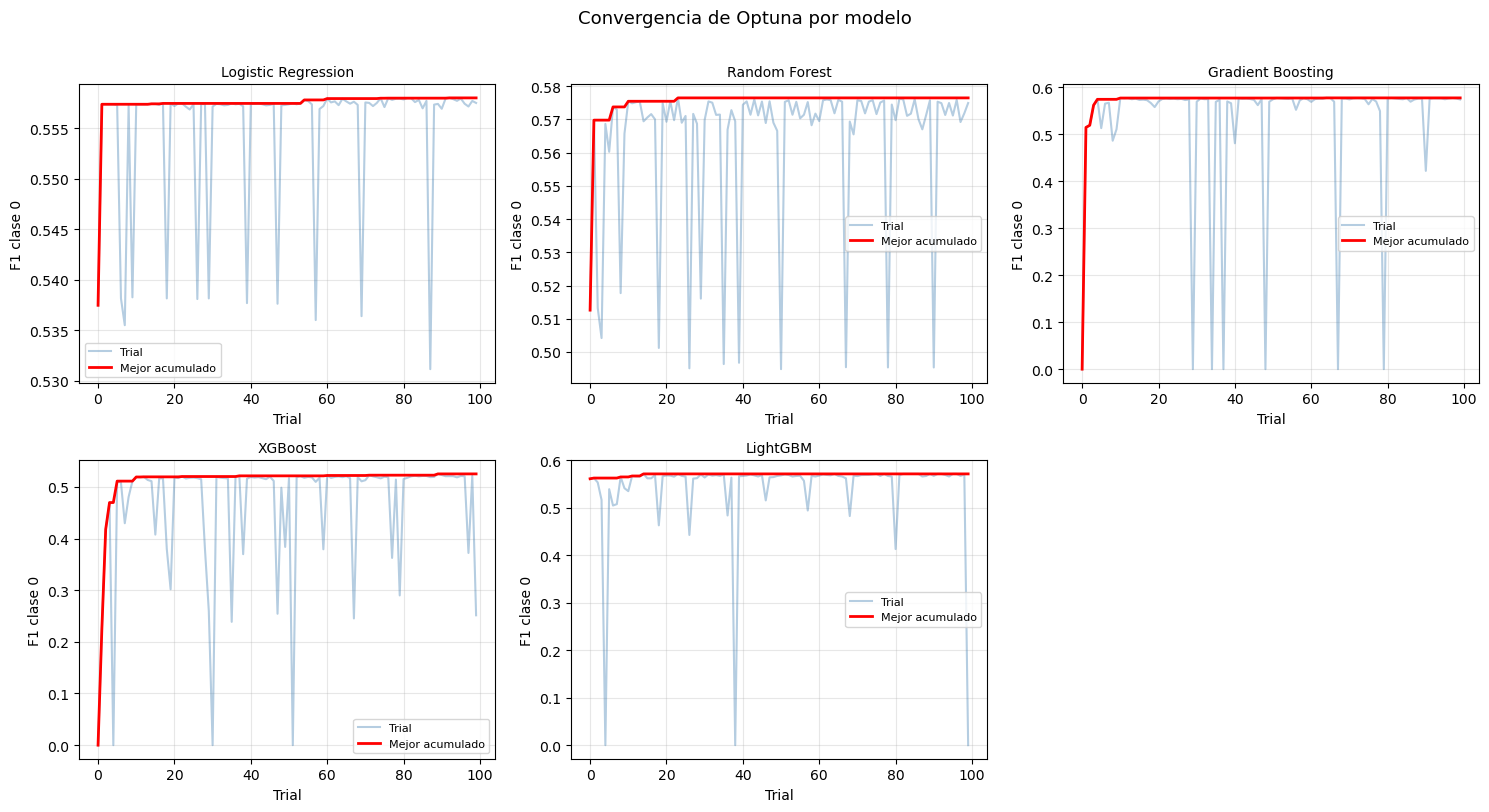

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (nombre, study) in enumerate(estudios_completados.items()):
    valores = [t.value for t in study.trials if t.value is not None]
    mejor_acumulado = np.maximum.accumulate(valores)

    ax = axes[i]
    ax.plot(valores, alpha=0.4, color='steelblue', label='Trial')
    ax.plot(mejor_acumulado, color='red', lw=2, label='Mejor acumulado')
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel('Trial')
    ax.set_ylabel('F1 clase 0')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for j in range(len(estudios_completados), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Convergencia de Optuna por modelo', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('optuna_convergencia.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Importancia de hiperparámetros (Optuna)

Optuna puede estimar qué hiperparámetros tuvieron más impacto en el resultado. Útil para saber dónde concentrar búsquedas futuras.

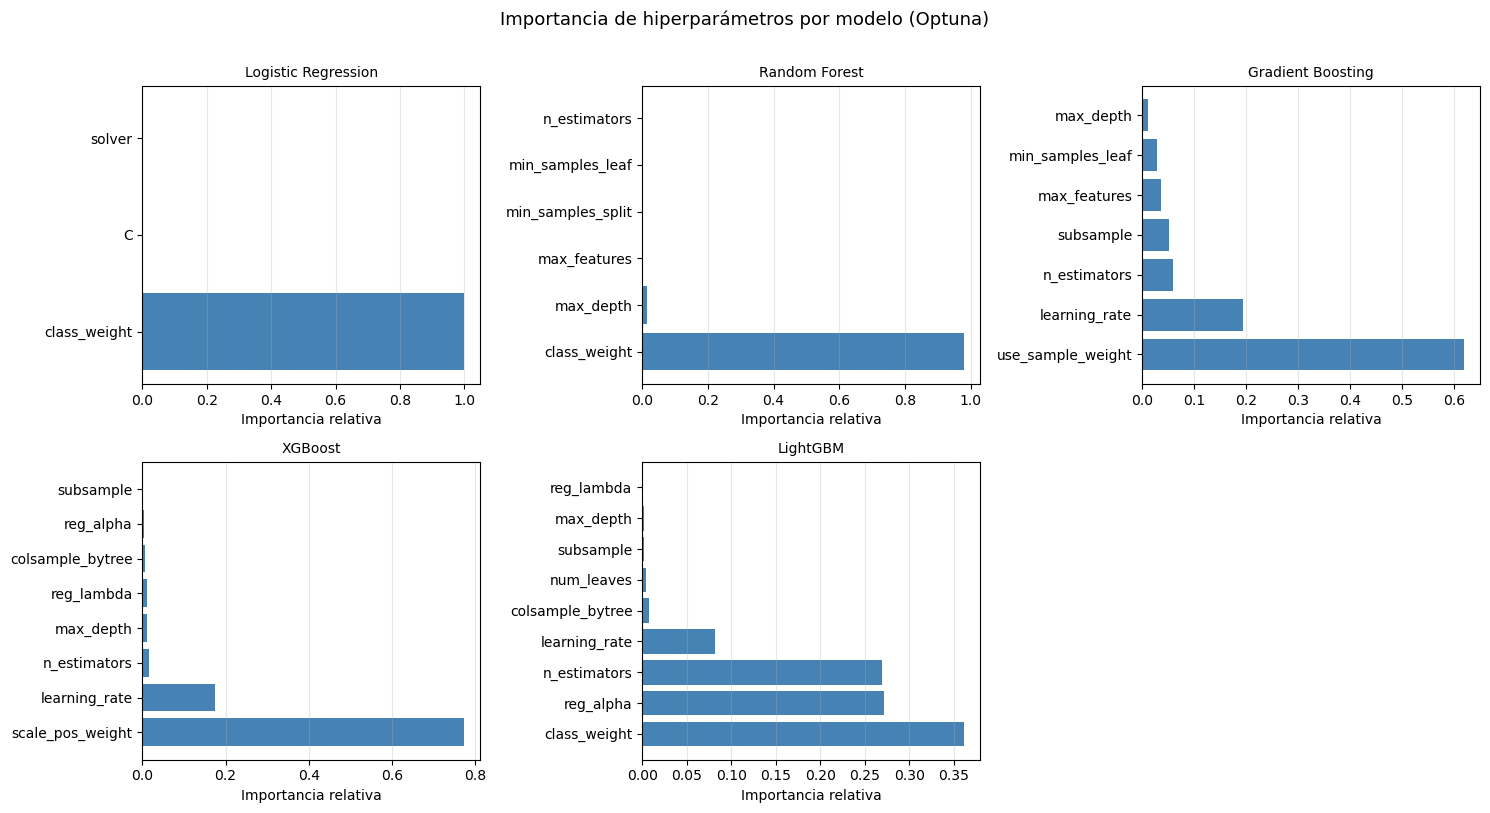

In [34]:
from optuna.importance import get_param_importances

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (nombre, study) in enumerate(estudios_completados.items()):
    try:
        importancias = get_param_importances(study)
        params_names = list(importancias.keys())
        valores_imp  = list(importancias.values())

        ax = axes[i]
        ax.barh(params_names, valores_imp, color='steelblue')
        ax.set_title(f'{nombre}', fontsize=10)
        ax.set_xlabel('Importancia relativa')
        ax.grid(axis='x', alpha=0.3)
    except Exception as e:
        axes[i].set_title(f'{nombre}\n(no disponible: {e})', fontsize=9)

for j in range(len(estudios_completados), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Importancia de hiperparámetros por modelo (Optuna)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('optuna_param_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Evaluación final en TEST del modelo ganador

⚠️ Solo correr esta celda una vez, después de haber elegido el modelo definitivo.

Modelo ganador: Gradient Boosting
  F1(cls 0) val : 0.5774
  AUC-ROC   val : 0.7582
  Parámetros    : {'n_estimators': 316, 'max_depth': 2, 'learning_rate': 0.0010347078751807833, 'subsample': 0.9238825823691569, 'min_samples_leaf': 18, 'max_features': 'log2', 'use_sample_weight': True}

RESULTADOS EN TEST (conjunto no visto)
  F1 clase 0  : 0.3990
  Recall cls 0: 0.3636
  Prec   cls 0: 0.4420
  F1 macro    : 0.6389
  AUC-ROC     : 0.6722


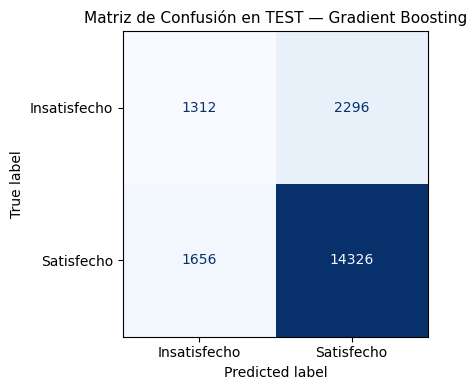


⚠️  El test set ya fue usado. No volver a modificar el modelo.


In [35]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Modelo ganador = mayor F1 clase 0 en validación
ganador = max(resultados_optuna, key=lambda x: x['F1(cls 0)'])
print(f'Modelo ganador: {ganador["Modelo"]}')
print(f'  F1(cls 0) val : {ganador["F1(cls 0)"]}')
print(f'  AUC-ROC   val : {ganador["AUC-ROC"]}')
print(f'  Parámetros    : {ganador["_params"]}')
print()

# ── Evaluación en TEST ────────────────────────────────────────────────────────
model_final = ganador['_model']
proba_test  = model_final.predict_proba(X_test)[:, 1]
pred_test   = (proba_test >= 0.5).astype(int)
m_test      = metricas(y_test, pred_test, proba_test)

print('=' * 45)
print('RESULTADOS EN TEST (conjunto no visto)')
print('=' * 45)
print(f'  F1 clase 0  : {m_test["f1_0"]:.4f}')
print(f'  Recall cls 0: {m_test["recall_0"]:.4f}')
print(f'  Prec   cls 0: {m_test["prec_0"]:.4f}')
print(f'  F1 macro    : {m_test["f1_macro"]:.4f}')
print(f'  AUC-ROC     : {m_test["auc"]:.4f}')

# Matriz de confusión en test
cm = confusion_matrix(y_test, pred_test)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Insatisfecho', 'Satisfecho']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Matriz de Confusión en TEST — {ganador["Modelo"]}', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_test_final.png', dpi=150)
plt.show()

print('\n⚠️  El test set ya fue usado. No volver a modificar el modelo.')

## 11. Resumen ejecutivo

In [36]:
print('=' * 55)
print('RESUMEN STAGE 4 — HIPERPARAMETRIZACIÓN CON OPTUNA')
print('=' * 55)
print(df_optuna.drop(columns=[]).to_string(index=False))
print()
print(f'→ Modelo ganador: {ganador["Modelo"]}')
print(f'  F1(cls 0) val : {ganador["F1(cls 0)"]}')
print(f'  F1(cls 0) test: {m_test["f1_0"]:.4f}')
print(f'  AUC-ROC  test : {m_test["auc"]:.4f}')
print()
print('PRÓXIMO PASO: Análisis de errores + umbral de decisión de negocio')

RESUMEN STAGE 4 — HIPERPARAMETRIZACIÓN CON OPTUNA
             Modelo  F1(cls 0)  Rec(cls 0)  Pre(cls 0)  F1 macro  AUC-ROC
  Gradient Boosting     0.5774      0.5527      0.6044    0.7139   0.7582
      Random Forest     0.5765      0.5718      0.5813    0.7096   0.7613
           LightGBM     0.5717      0.5750      0.5684    0.7047   0.7559
Logistic Regression     0.5580      0.6701      0.4781    0.6712   0.7631
            XGBoost     0.5251      0.3810      0.8446    0.7039   0.7656

→ Modelo ganador: Gradient Boosting
  F1(cls 0) val : 0.5774
  F1(cls 0) test: 0.3990
  AUC-ROC  test : 0.6722

PRÓXIMO PASO: Análisis de errores + umbral de decisión de negocio
